In [24]:
using PyPlot
using JLD2
using Statistics
import PhysicalConstants.CODATA2018: h, c_0, ħ
using Unitful

In [25]:
pathdir = "Y:/TwoDGas/2025/07/04"
size_pxl = 0.187e-6
λ = 421e-9
γ = 32.7e6 # In Hz
Γ = 2.02e8 # In Hz
ν = ustrip(c_0)/λ
ω0 = 2π*ν

Isat = ustrip(ħ)*Γ*ω0^3 / (12*π*ustrip(c_0)^2);

In [26]:
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds;

In [27]:
i, j = 6, 1
img_test = Imgs_bkg_crop_ds[i, j, :, :];

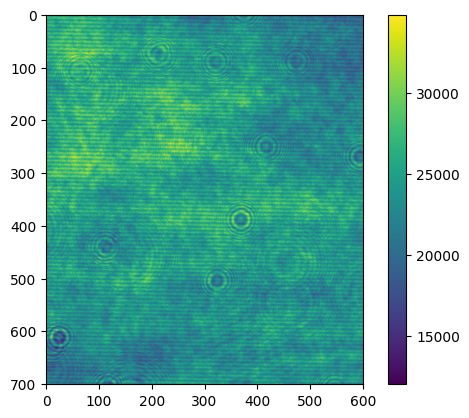

In [28]:
close("all")
fig = subplots()
img = imshow(img_test)
colorbar(img)
pygui(false);

In [29]:
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
else
    Convertion_factor = 0.107 / (0.85 * τ_exp[i])
end
img_test *= Convertion_factor
img_test /= size(img_test)[1]*size(img_test)[2]*size_pxl^2; # Photon s^-1 m^-2

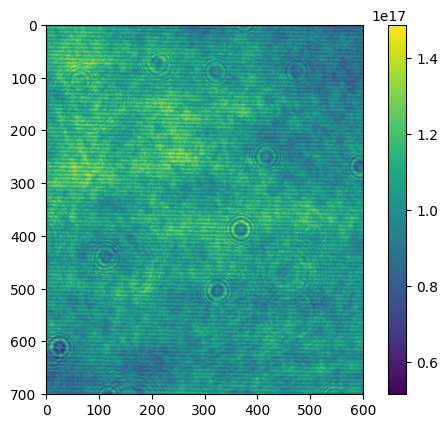

In [30]:
close("all")
fig = subplots()
img = imshow(img_test)
colorbar(img)
pygui(false);

In [31]:
println("Total intensity = $(sum(img_test)) photon s^-1 m^-2")
println("Total intensity = $(sum(img_test)*ustrip(h)*ν) W m^-2")
println("Power of the laser = $(sum(img_test)*ustrip(h)*ν * π  * (320e-6)^2 / 2) W")
println("Sat = $((sum(img_test)*ustrip(h)*ν)/Isat)")

Total intensity = 4.368192007583952e22 photon s^-1 m^-2
Total intensity = 20610.871536095492 W m^-2
Power of the laser = 0.0033152492852162856 W
Sat = 36.60040778642576
